<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Filter001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# --- Cell 1: Setup + FD run (shadow) ---

import numpy as np

# Parameters
N = 64
steps = 20
dt = 5e-3   # timestep
chi   = 1.0
mu    = 0.10
beta  = 0.05
gamma = 0.12
beta_link = 0.08
kappa = 8.64e-4  # gentle back-pressure

rng = np.random.default_rng(42)
Phi0 = rng.normal(0, 1e-2, size=(N, N, N))

def l2_per_site(a):
    return np.linalg.norm(a) / a.size

# --- Finite-difference operators ---
def fd_lap(phi):
    return (np.roll(phi, -1, 0) + np.roll(phi, +1, 0) +
            np.roll(phi, -1, 1) + np.roll(phi, +1, 1) +
            np.roll(phi, -1, 2) + np.roll(phi, +1, 2) - 6*phi)

def fd_grad(phi, axis):
    return 0.5 * (np.roll(phi, -1, axis) - np.roll(phi, +1, axis))

# --- FD update rule ---
def update_fd(Phi):
    lap = fd_lap(Phi)
    tanh_term = gamma * np.tanh(Phi)
    de_term   = kappa * Phi**4
    return Phi + dt * (chi*lap + mu*tanh_term - beta*Phi + de_term)

# --- FD diagnostics ---
def diagnostics_fd(Phi):
    dpx = fd_grad(Phi, 0); dpy = fd_grad(Phi, 1); dpz = fd_grad(Phi, 2)
    lap = fd_lap(Phi)
    G00 = 2.0 * lap
    grad_sq = dpx**2 + dpy**2 + dpz**2
    T00 = grad_sq + kappa * (Phi**4)
    coeff = 8.0 * np.pi
    R00 = l2_per_site(G00 - coeff*T00)
    B = l2_per_site(lap - G00/2.0)
    return R00, B

# --- Run FD track ---
Phi_fd = Phi0.copy()
log_fd = []
for s in range(steps):
    Phi_fd = update_fd(Phi_fd)
    R00, B = diagnostics_fd(Phi_fd)
    log_fd.append((R00, B))

print("FD track done.")


FD track done.


/tmp/ipython-input-1579358199.py:44: RuntimeWarning: overflow encountered in power
  T00 = grad_sq + kappa * (Phi**4)
/tmp/ipython-input-1579358199.py:32: RuntimeWarning: overflow encountered in power
  de_term   = kappa * Phi**4
/usr/local/lib/python3.12/dist-packages/numpy/fft/_pocketfft.py:94: RuntimeWarning: invalid value encountered in fft
  return ufunc(a, fct, axes=[(axis,), (), (axis,)], out=out)
/tmp/ipython-input-1579358199.py:13: RuntimeWarning: invalid value encountered in multiply
  dpx = np.fft.ifftn(1j*KX*phik).real
/tmp/ipython-input-1579358199.py:14: RuntimeWarning: invalid value encountered in multiply
  dpy = np.fft.ifftn(1j*KY*phik).real
/tmp/ipython-input-1579358199.py:15: RuntimeWarning: invalid value encountered in multiply
  dpz = np.fft.ifftn(1j*KZ*phik).real
/tmp/ipython-input-1579358199.py:20: RuntimeWarning: invalid value encountered in multiply
  return np.fft.ifftn(-K2*phik).real


Spectral tracks done.


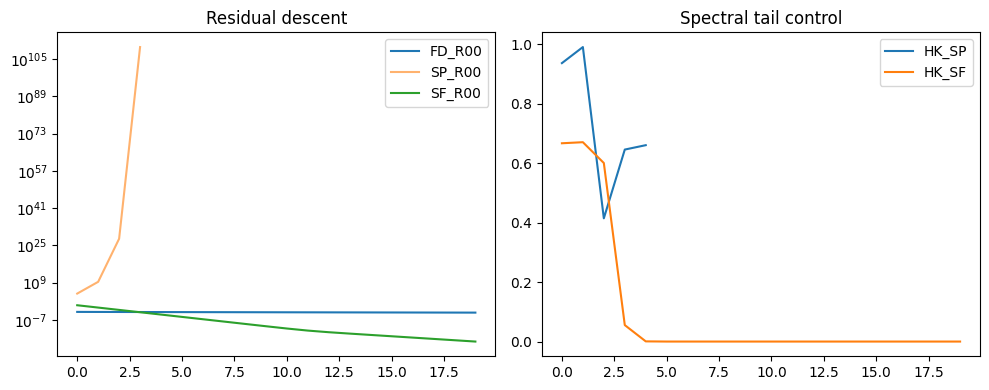

In [7]:
# --- Cell 2: Spectral run + Filter Covenant + Plots ---

# Spectral grids
kx = 2*np.pi*np.fft.fftfreq(N, d=1.0/N)
ky = 2*np.pi*np.fft.fftfreq(N, d=1.0/N)
kz = 2*np.pi*np.fft.fftfreq(N, d=1.0/N)
KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
K2 = KX**2 + KY**2 + KZ**2

# Spectral operators
def sp_grad(phi):
    phik = np.fft.fftn(phi)
    dpx = np.fft.ifftn(1j*KX*phik).real
    dpy = np.fft.ifftn(1j*KY*phik).real
    dpz = np.fft.ifftn(1j*KZ*phik).real
    return dpx, dpy, dpz

def sp_lap(phi):
    phik = np.fft.fftn(phi)
    return np.fft.ifftn(-K2*phik).real

def apply_filter(phi, eps):
    phik = np.fft.fftn(phi)
    filt = 1.0 / (1.0 + eps * K2)
    phik *= filt
    return np.fft.ifftn(phik).real

# Spectral update
def update_sp(Phi, eps=0.0):
    lap = sp_lap(Phi)
    tanh_term = gamma * np.tanh(Phi)
    de_term   = kappa * Phi**4
    Phi_new = Phi + dt * (chi*lap + mu*tanh_term - beta*Phi + de_term)
    if eps > 0.0:
        Phi_new = apply_filter(Phi_new, eps)
    return Phi_new

# Spectral diagnostics
def diagnostics_sp(Phi):
    dpx, dpy, dpz = sp_grad(Phi)
    lap = sp_lap(Phi)
    G00 = 2.0 * lap
    grad_sq = dpx**2 + dpy**2 + dpz**2
    T00 = grad_sq + kappa * (Phi**4)
    coeff = 8.0 * np.pi
    R00 = l2_per_site(G00 - coeff*T00)
    B = l2_per_site(lap - G00/2.0)
    return R00, B

def high_k_fraction(phi, k_cut_ratio=0.5):
    phik = np.fft.fftn(phi)
    power = np.abs(phik)**2
    k_mag = np.sqrt(K2)
    k_cut = k_cut_ratio * np.max(k_mag)
    mask = k_mag > k_cut
    return power[mask].sum() / power.sum()

# Run FFT-only and FFT+filter tracks
Phi_sp = Phi0.copy()
Phi_sf = Phi0.copy()
eps = 5e-2  # stronger filter

log_sp, log_sf = [], []
hk_sp, hk_sf = [], []

for s in range(steps):
    Phi_sp = update_sp(Phi_sp, eps=0.0)
    R00, B = diagnostics_sp(Phi_sp)
    log_sp.append((R00, B))
    hk_sp.append(high_k_fraction(Phi_sp))

    Phi_sf = update_sp(Phi_sf, eps=eps)
    R00f, Bf = diagnostics_sp(Phi_sf)
    log_sf.append((R00f, Bf))
    hk_sf.append(high_k_fraction(Phi_sf))

print("Spectral tracks done.")

# --- Plotting ---
import matplotlib.pyplot as plt

steps_arr = np.arange(len(log_fd))

R_fd = [r for r,_ in log_fd]
R_sp = [r for r,_ in log_sp]
R_sf = [r for r,_ in log_sf]

fig, ax = plt.subplots(1,2, figsize=(10,4))

# Residuals
ax[0].semilogy(steps_arr, R_fd, label='FD_R00')
ax[0].semilogy(steps_arr, R_sp, label='SP_R00', alpha=0.6)
ax[0].semilogy(steps_arr, R_sf, label='SF_R00')
ax[0].set_title('Residual descent')
ax[0].legend()

# High-k fraction
ax[1].plot(steps_arr, hk_sp, label='HK_SP')
ax[1].plot(steps_arr, hk_sf, label='HK_SF')
ax[1].set_title('Spectral tail control')
ax[1].legend()

plt.tight_layout()
plt.show()
